In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_pla_30322.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_ani_10197.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_nat_00098.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_nat_30407.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_arc_20034.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_sec_30053.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_pla_30069.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_nat_30645.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_cha_30461.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_arc_30140.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_txt_00100.jpg
/kaggle/input/datasets/sophatvathana/casia-dataset/casia/CASIA2/Au/Au_arc_30

In [2]:
import os
import glob
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch
import torch.nn as nn
import torch.nn.functional as F


path_casia1 = '/kaggle/input/datasets/sophatvathana/casia-dataset/CASIA1'
path_casia2 = '/kaggle/input/datasets/sophatvathana/casia-dataset/CASIA2'

def get_data():
    paths, labels = [], []
    for base in [path_casia1, path_casia2]:
        for ext in ('**/*.jpg', '**/*.png', '**/*.tif'):
            for p in glob.glob(os.path.join(base, ext), recursive=True):
                paths.append(p)
                labels.append(0 if os.path.basename(p).startswith('Au') else 1)
    return pd.DataFrame({'path': paths, 'label': labels})

df = get_data()
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

#Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class CasiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.df.iloc[idx]['label']

train_loader = DataLoader(CasiaDataset(train_df, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(CasiaDataset(val_df, val_transform), batch_size=32)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

teacher = models.resnet101(weights='IMAGENET1K_V1').to(device)
teacher.fc = nn.Linear(teacher.fc.in_features, 2).to(device) # فئتين فقط
teacher.eval()     

student = models.resnet50(weights='IMAGENET1K_V1').to(device)
student.fc = nn.Linear(student.fc.in_features, 2).to(device)

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 168MB/s]  


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 153MB/s] 


In [4]:
def distillation_loss(student_logits, teacher_logits, labels, T=4.0, alpha=0.3):
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1)
    ) * (alpha * T * T)
    
    hard_loss = F.cross_entropy(student_logits, labels) * (1. - alpha)
    
    return soft_loss + hard_loss

In [5]:
optimizer = torch.optim.AdamW(student.parameters(), lr=1e-4)

In [6]:
history = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': []
}

def train_kd(epochs=15):
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        student.train()
        train_loss = 0.0
        train_correct, train_total = 0, 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            with torch.no_grad():
                teacher_logits = teacher(imgs)
            
            student_logits = student(imgs)
            loss = distillation_loss(student_logits, teacher_logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, pred = torch.max(student_logits, 1)
            train_total += labels.size(0)
            train_correct += (pred == labels).sum().item()
            
        # Validation
        student.eval()
        val_correct, val_total = 0, 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = student(imgs)
                _, pred = torch.max(outputs, 1)
                
                val_total += labels.size(0)
                val_correct += (pred == labels).sum().item()
                
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # history
        epoch_train_acc = 100 * train_correct / train_total
        epoch_val_acc = 100 * val_correct / val_total
        
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['train_loss'].append(train_loss / len(train_loader))
        
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")
        print("-" * 30)
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(student.state_dict(), 'best_student_model.pth')
            
    return all_labels, all_preds

y_true, y_pred = train_kd(epochs=15)

Epoch [1/15]
Train Acc: 69.85% | Val Acc: 78.29%
------------------------------
Epoch [2/15]
Train Acc: 76.99% | Val Acc: 71.60%
------------------------------
Epoch [3/15]
Train Acc: 79.88% | Val Acc: 78.15%
------------------------------
Epoch [4/15]
Train Acc: 81.12% | Val Acc: 78.79%
------------------------------
Epoch [5/15]
Train Acc: 82.00% | Val Acc: 72.41%
------------------------------
Epoch [6/15]
Train Acc: 83.37% | Val Acc: 78.68%
------------------------------
Epoch [7/15]
Train Acc: 83.73% | Val Acc: 78.08%
------------------------------
Epoch [8/15]
Train Acc: 84.45% | Val Acc: 76.92%
------------------------------
Epoch [9/15]
Train Acc: 85.34% | Val Acc: 81.01%
------------------------------
Epoch [10/15]
Train Acc: 85.61% | Val Acc: 81.15%
------------------------------
Epoch [11/15]
Train Acc: 86.30% | Val Acc: 78.01%
------------------------------
Epoch [12/15]
Train Acc: 86.96% | Val Acc: 82.56%
------------------------------
Epoch [13/15]
Train Acc: 87.29% | Val

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_performance(train_acc_history, val_acc_history, y_true, y_pred):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_acc_history, label='Training Accuracy', color='blue', marker='o')
    plt.plot(val_acc_history, label='Validation Accuracy', color='orange', marker='s')
    plt.title('Training vs Validation Accuracy (Knowledge Distillation)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Authentic', 'Tampered'], 
                yticklabels=['Authentic', 'Tampered'])
    plt.title('Final Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()

    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Authentic', 'Tampered']))



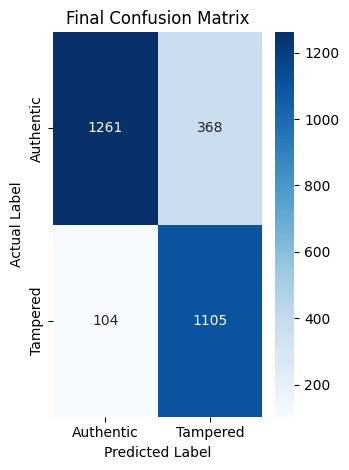

In [9]:
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Authentic', 'Tampered'], 
            yticklabels=['Authentic', 'Tampered'])
plt.title('Final Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
    
plt.tight_layout()
plt.show()

In [10]:
def extract_distilled_features(model, loader, device):
    model.eval()
    feature_extractor = torch.nn.Sequential(*(list(model.children())[:-1]))
    
    features, labels = [], []
    print("Extracting distilled features...")
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            fts = feature_extractor(imgs).view(imgs.size(0), -1)
            features.append(fts.cpu().numpy())
            labels.append(lbls.numpy())
            
    return np.concatenate(features), np.concatenate(labels)

full_loader = DataLoader(CasiaDataset(df, val_transform), batch_size=32, shuffle=False)
X_features, y_labels = extract_distilled_features(student, full_loader, device)

Extracting distilled features...


In [11]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

print(f"Starting 5-Fold Cross-Validation with XGBoost...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_features, y_labels)):
    X_train_kf, X_val_kf = X_features[train_idx], X_features[val_idx]
    y_train_kf, y_val_kf = y_labels[train_idx], y_labels[val_idx]
    
    boost_model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=6,
        tree_method='hist',
        device='cuda',
        random_state=42
    )
    
    boost_model.fit(X_train_kf, y_train_kf)
    
    # التقييم لهذا الـ Fold
    preds = boost_model.predict(X_val_kf)
    acc = accuracy_score(y_val_kf, preds)
    fold_accuracies.append(acc)
    
    print(f"Fold {fold+1}: Accuracy = {acc*100:.2f}%")

print(f"\nAverage K-Fold Accuracy: {np.mean(fold_accuracies)*100:.2f}%")

Starting 5-Fold Cross-Validation with XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:02:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold 1: Accuracy = 90.70%
Fold 2: Accuracy = 92.00%
Fold 3: Accuracy = 91.09%
Fold 4: Accuracy = 90.02%
Fold 5: Accuracy = 91.33%

Average K-Fold Accuracy: 91.03%


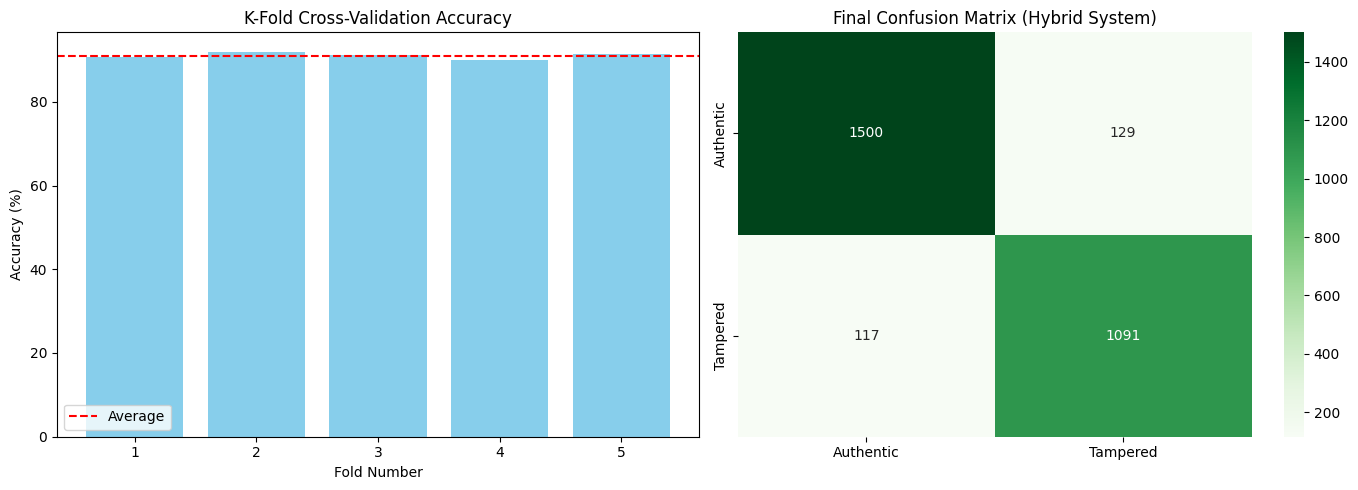


Final Classification Report:
              precision    recall  f1-score   support

   Authentic       0.93      0.92      0.92      1629
    Tampered       0.89      0.90      0.90      1208

    accuracy                           0.91      2837
   macro avg       0.91      0.91      0.91      2837
weighted avg       0.91      0.91      0.91      2837



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_final_evaluation(y_true, y_pred, fold_accs):
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(1, 6), [a*100 for a in fold_accs], color='skyblue')
    plt.axhline(y=np.mean(fold_accs)*100, color='red', linestyle='--', label='Average')
    plt.title('K-Fold Cross-Validation Accuracy')
    plt.xlabel('Fold Number')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Authentic', 'Tampered'], 
                yticklabels=['Authentic', 'Tampered'])
    plt.title('Final Confusion Matrix (Hybrid System)')
    
    plt.tight_layout()
    plt.show()

    print("\nFinal Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Authentic', 'Tampered']))


plot_final_evaluation(y_val_kf, preds, fold_accuracies)

In [15]:
import numpy as np
import scipy.ndimage as ndimage
from PIL import Image

def extract_srm_features(img_paths):
    srm_kernel = np.array([[-1, 2, -1],
                           [ 2,-4,  2],
                           [-1, 2, -1]])
    
    srm_features = []
    print(f"Extracting SRM for {len(img_paths)} images...")
    for path in img_paths:
        try:
            img = Image.open(path).convert('L').resize((128, 128))
            img_arr = np.array(img, dtype=float)
            res = ndimage.convolve(img_arr, srm_kernel)
            srm_features.append([np.mean(res), np.std(res), np.var(res), np.max(res)])
        except:
            srm_features.append(np.zeros(4))
    return np.array(srm_features)

In [16]:
from skimage.feature import local_binary_pattern

def extract_lbp_features(img_paths):
    lbp_features = []
    print(f"Extracting LBP for {len(img_paths)} images...")
    for path in img_paths:
        try:
            img = Image.open(path).convert('L').resize((128, 128))
            img_arr = np.array(img)
            lbp = local_binary_pattern(img_arr, P=8, R=1, method='uniform')
            (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-7)
            lbp_features.append(hist)
        except:
            lbp_features.append(np.zeros(10))
    return np.array(lbp_features)

In [17]:
X_srm_full = extract_srm_features(df['path'].tolist())
X_lbp_full = extract_lbp_features(df['path'].tolist())

X_combined_final = np.hstack((X_features, X_srm_full, X_lbp_full))

print(f"Final Feature Vector Shape: {X_combined_final.shape}")



Extracting SRM for 14188 images...
Extracting LBP for 14188 images...
Final Feature Vector Shape: (14188, 2062)


In [19]:
print("--- Step 1: Combining Forensic Features ---")
X_forensic_full = np.hstack((X_srm_full, X_lbp_full)) 

X_combined_final = np.hstack((X_features, X_forensic_full))
y_final = y_labels 

print(f"Final Combined Feature Vector Shape: {X_combined_final.shape}")

from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_accuracies = []

print("\n--- Step 2: Running Final K-Fold with Fusion ---")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_combined_final, y_final)):
    X_train_kf, X_val_kf = X_combined_final[train_idx], X_combined_final[val_idx]
    y_train_kf, y_val_kf = y_final[train_idx], y_final[val_idx]
    
    # الـ Boost النهائي
    final_boost_model = XGBClassifier(
        n_estimators=1500,
        learning_rate=0.01,
        max_depth=10,
        subsample=0.9,
        colsample_bytree=0.8,
        tree_method='hist',
        device='cuda',
        random_state=42
    )
    
    final_boost_model.fit(X_train_kf, y_train_kf)
    
    preds = final_boost_model.predict(X_val_kf)
    acc = accuracy_score(y_val_kf, preds)
    final_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")

print("\n" + "="*45)
print(f"ULTIMATE HYBRID SYSTEM AVERAGE ACCURACY: {np.mean(final_accuracies)*100:.2f}%")
print("="*45)

--- Step 1: Combining Forensic Features ---
Final Combined Feature Vector Shape: (14188, 2062)

--- Step 2: Running Final K-Fold with Fusion ---
Fold 1 Accuracy: 90.59%
Fold 2 Accuracy: 91.54%
Fold 3 Accuracy: 91.33%
Fold 4 Accuracy: 89.85%
Fold 5 Accuracy: 90.94%

ULTIMATE HYBRID SYSTEM AVERAGE ACCURACY: 90.85%


In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined_final)

pca = PCA(n_components=0.95) 
X_pca = pca.fit_transform(X_scaled)

print(f"Features reduced from {X_combined_final.shape[1]} to {X_pca.shape[1]} after PCA")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pca, y_final)):
    X_train_kf, X_val_kf = X_pca[train_idx], X_pca[val_idx]
    y_train_kf, y_val_kf = y_final[train_idx], y_final[val_idx]
    
    final_boost = XGBClassifier(
        n_estimators=2000,
        learning_rate=0.005,      
        max_depth=12,          
        min_child_weight=2,       
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,            # L1 Regularization
        reg_lambda=1.0,           # L2 Regularization
        tree_method='hist',
        device='cuda',
        random_state=42
    )
    
    final_boost.fit(X_train_kf, y_train_kf)
    acc = accuracy_score(y_val_kf, final_boost.predict(X_val_kf))
    final_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")

print(f"\nNEW AVERAGE ACCURACY: {np.mean(final_accuracies)*100:.2f}%")

Features reduced from 2062 to 119 after PCA
Fold 1 Accuracy: 90.73%
Fold 2 Accuracy: 91.12%
Fold 3 Accuracy: 90.73%
Fold 4 Accuracy: 89.99%
Fold 5 Accuracy: 90.94%

NEW AVERAGE ACCURACY: 90.70%


In [21]:
def extract_ela_features(img_paths, quality=90):
    ela_features = []
    print(f"Extracting ELA features for {len(img_paths)} images...")
    
    for path in img_paths:
        try:
            original = Image.open(path).convert('RGB')
            temp_path = 'temp_ela.jpg'
            original.save(temp_path, 'JPEG', quality=quality)
            
            compressed = Image.open(temp_path)
            ela_img = ImageChops.difference(original, compressed)
            
            extrema = ela_img.getextrema()
            max_diff = max([ex[1] for ex in extrema])
            if max_diff == 0: max_diff = 1
            scale = 255.0 / max_diff
            
            ela_img = ImageEnhance.Brightness(ela_img).enhance(scale)
            ela_arr = np.array(ela_img)
            
            ela_features.append([np.mean(ela_arr), np.std(ela_arr), np.max(ela_arr)])
        except:
            ela_features.append([0, 0, 0])
            
    return np.array(ela_features)

In [22]:
from sklearn.ensemble import VotingClassifier
from lightgbm import LGBMClassifier

X_ela_full = extract_ela_features(df['path'].tolist())

X_final_all = np.hstack((X_combined_final, X_ela_full)) 

clf1 = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=10, device='cuda')
clf2 = LGBMClassifier(n_estimators=1000, learning_rate=0.01, num_leaves=31)

voting_clf = VotingClassifier(
    estimators=[('xgb', clf1), ('lgbm', clf2)],
    voting='soft' 
)


Extracting ELA features for 14188 images...


Extracting SRM, LBP, and ELA features
Final Feature Vector Shape: (14188, 2065)

Running Final 5-Fold Cross-Validation with Ensemble Voting...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 Accuracy: 91.54%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 Accuracy: 92.64%


...

Fold 3 Accuracy: 92.11%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 Accuracy: 90.94%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5 Accuracy: 92.21%

FINAL SYSTEM AVERAGE ACCURACY: 91.89%


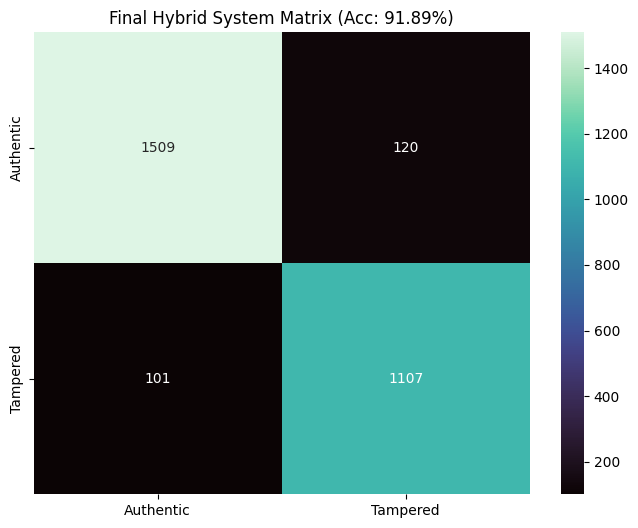


Final Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1629
           1       0.90      0.92      0.91      1208

    accuracy                           0.92      2837
   macro avg       0.92      0.92      0.92      2837
weighted avg       0.92      0.92      0.92      2837



In [24]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageChops, ImageEnhance
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import scipy.ndimage as ndimage
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import seaborn as sns
import os


def extract_srm_features(img_paths):
    srm_kernel = np.array([[-1, 2, -1], [2, -4, 2], [-1, 2, -1]])
    features = []
    for path in img_paths:
        try:
            img = Image.open(path).convert('L').resize((128, 128))
            res = ndimage.convolve(np.array(img, dtype=float), srm_kernel)
            features.append([np.mean(res), np.std(res), np.var(res), np.max(res)])
        except: features.append(np.zeros(4))
    return np.array(features)

def extract_lbp_features(img_paths):
    features = []
    for path in img_paths:
        try:
            img = Image.open(path).convert('L').resize((128, 128))
            lbp = local_binary_pattern(np.array(img), P=8, R=1, method='uniform')
            (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
            hist = hist.astype("float"); hist /= (hist.sum() + 1e-7)
            features.append(hist)
        except: features.append(np.zeros(10))
    return np.array(features)

def extract_ela_features(img_paths, quality=90):
    features = []
    for path in img_paths:
        try:
            original = Image.open(path).convert('RGB')
            original.save('temp.jpg', 'JPEG', quality=quality)
            compressed = Image.open('temp.jpg')
            ela_img = ImageChops.difference(original, compressed)
            extrema = ela_img.getextrema()
            max_diff = max([ex[1] for ex in extrema]) or 1
            scale = 255.0 / max_diff
            ela_img = ImageEnhance.Brightness(ela_img).enhance(scale)
            ela_arr = np.array(ela_img)
            features.append([np.mean(ela_arr), np.std(ela_arr), np.max(ela_arr)])
        except: features.append([0, 0, 0])
    return np.array(features)



print("Extracting SRM, LBP, and ELA features")
X_srm = extract_srm_features(df['path'].tolist())
X_lbp = extract_lbp_features(df['path'].tolist())
X_ela = extract_ela_features(df['path'].tolist())

X_ultimate = np.hstack((X_features, X_srm, X_lbp, X_ela))
y_ultimate = y_labels

print(f"Final Feature Vector Shape: {X_ultimate.shape}")


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_accs = []
final_y_true, final_y_pred = [], []

print("\nRunning Final 5-Fold Cross-Validation with Ensemble Voting...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_ultimate, y_ultimate)):
    X_t, X_v = X_ultimate[train_idx], X_ultimate[val_idx]
    y_t, y_v = y_ultimate[train_idx], y_ultimate[val_idx]
    
    xgb = XGBClassifier(n_estimators=1200, learning_rate=0.01, max_depth=10, 
                        tree_method='hist', device='cuda', random_state=42)
    
    lgbm = LGBMClassifier(n_estimators=1200, learning_rate=0.01, num_leaves=63, 
                          random_state=42, verbose=-1)
    
    voting_model = VotingClassifier(estimators=[('xgb', xgb), ('lgbm', lgbm)], voting='soft')
    
    voting_model.fit(X_t, y_t)
    preds = voting_model.predict(X_v)
    
    acc = accuracy_score(y_v, preds)
    final_accs.append(acc)
    
    if fold == 4: 
        final_y_true = y_v
        final_y_pred = preds
        
    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")


avg_accuracy = np.mean(final_accs) * 100
print("\n" + "="*45)
print(f"FINAL SYSTEM AVERAGE ACCURACY: {avg_accuracy:.2f}%")
print("="*45)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(final_y_true, final_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', 
            xticklabels=['Authentic', 'Tampered'], yticklabels=['Authentic', 'Tampered'])
plt.title(f'Final Hybrid System Matrix (Acc: {avg_accuracy:.2f}%)')
plt.show()

print("\nFinal Classification Report:")
print(classification_report(final_y_true, final_y_pred))